# Business Case: Aerofit - Descriptive Statistics & Probability

# About Aerofit

Aerofit is a leading brand in the field of fitness equipment. Aerofit provides a product range including machines such as treadmills, exercise bikes, gym equipment, and fitness accessories to cater to the needs of all categories of people.

# Business Problem

The market research team at AeroFit wants to identify the characteristics of the target audience for each type of treadmill offered by the company, to provide a better recommendation of the treadmills to the new customers.

# Dataset

The company collected the df on individuals who purchased a treadmill from the AeroFit stores during the prior three months. The dfset has the following features:

* Product Purchased:	KP281, KP481, or KP781
* Age:	In years
* Gender:	Male/Female
* Education:	In years
* MaritalStatus:	Single or partnered
* Usage:	The average number of times the customer plans to use the treadmill each week.
* Income:	Annual income (in $)
* Fitness:	Self-rated fitness on a 1-to-5 scale, where 1 is the poor shape and 5 is the excellent shape.
* Miles:	The average number of miles the customer expects to walk/run each week

Product Portfolio:

- The KP281 is an entry-level treadmill that sells for $1,500.
- The KP481 is for mid-level runners that sell for $1,750.
- The KP781 treadmill is having advanced features that sell for $2,500.

In [1]:
# Import the necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importing the df

df = pd.read_csv(r"D:\Scaler\05 Data Analytics and Visualisation - Probability and Stats\Business Case Study\01 Aerofit - Descriptive Statistics & Probability\aerofit_treadmill.txt")

# 1. Defining Problem Statement and Analysing basic metrics

Observations on shape of data, data types of all the attributes, conversion of categorical attributes to 'category' (If required), statistical summary

In [3]:
df.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47


In [4]:
# Checking the shape of the df

df.shape

(180, 9)

In [5]:
# Checking the df types of the df

df.dtypes

Product          object
Age               int64
Gender           object
Education         int64
MaritalStatus    object
Usage             int64
Fitness           int64
Income            int64
Miles             int64
dtype: object

In [6]:
# Statistical summary

df.describe()

,Age,Education,Usage,Fitness,Income,Miles
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,28.788889,15.572222,3.455556,3.311111,53719.577778,103.194444
std,6.943498,1.617055,1.084797,0.958869,16506.684226,51.863605
min,18.000000,12.000000,2.000000,1.000000,29562.000000,21.000000
25%,24.000000,14.000000,3.000000,3.000000,44058.750000,66.000000
50%,26.000000,16.000000,3.000000,3.000000,50596.500000,94.000000
75%,33.000000,16.000000,4.000000,4.000000,58668.000000,114.750000
max,50.000000,21.000000,7.000000,5.000000,104581.000000,360.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        180 non-null    object
 1   Age            180 non-null    int64 
 2   Gender         180 non-null    object
 3   Education      180 non-null    int64 
 4   MaritalStatus  180 non-null    object
 5   Usage          180 non-null    int64 
 6   Fitness        180 non-null    int64 
 7   Income         180 non-null    int64 
 8   Miles          180 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 12.8+ KB


In [8]:
numerical_features = ['Age', 'Education', 'Usage', 'Fitness', 'Income', 'Miles']

In [9]:
# Check the difference between mean and median for each feature

mean_median_diff = df[numerical_features].agg(['mean', 'median'])

mean_median_diff.T

,mean,median
Age,28.788889,26.0
Education,15.572222,16.0
Usage,3.455556,3.0
Fitness,3.311111,3.0
Income,53719.577778,50596.5
Miles,103.194444,94.0


In [10]:
# Probability of a male customer buying a KP781 treadmill

total_male_customers = df[df['Gender']=='Male'].shape[0]

male_kp781 = df[(df['Gender']== 'Male') & (df['Product']=='KP781')].shape[0]

prob_male_kp781 = male_kp781 / total_male_customers

print(f'The number of Male Customer is: {total_male_customers}')

print(f'\nThe number of Male Customer who brought product KP781 is: {male_kp781}')

print(f'\nThe probability of a male customer buying a KP781 trendmill is: {prob_male_kp781:.2%}')

The number of Male Customer is: 104

The number of Male Customer who brought product KP781 is: 33

The probability of a male customer buying a KP781 trendmill is: 31.73%


In [11]:
# Customer Profiling - Categorization of users

bins_age = [17, 24, 34, 44, 54, 100]
labels_age = ['18-24', '25-34', '35-44', '45-54', '55+']

df['Age Group'] = pd.cut(df['Age'], bins=bins_age, labels=labels_age)

In [12]:
# Create income group

def income(income):
    if income < 40000:
        return 'Low'
    elif income <= 80000:
        return 'Medium'
    else:
        return 'High'


df['Income Group'] = df['Income'].apply(income)

In [13]:
df.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles,Age Group,Income Group
0,KP281,18,Male,14,Single,3,4,29562,112,18-24,Low
1,KP281,19,Male,15,Single,2,3,31836,75,18-24,Low
2,KP281,19,Female,14,Partnered,4,3,30699,66,18-24,Low
3,KP281,19,Male,12,Single,3,3,32973,85,18-24,Low
4,KP281,20,Male,13,Partnered,4,2,35247,47,18-24,Low


In [14]:
# Create fitness level

def fitness(fitness):
    if fitness <= 2:
        return "Poor"
    elif fitness == 3:
        return "Average"
    else:
        return "Good"
    
df['Fitness Group'] = df['Fitness'].apply(fitness)

In [15]:
df.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles,Age Group,Income Group,Fitness Group
0,KP281,18,Male,14,Single,3,4,29562,112,18-24,Low,Good
1,KP281,19,Male,15,Single,2,3,31836,75,18-24,Low,Average
2,KP281,19,Female,14,Partnered,4,3,30699,66,18-24,Low,Average
3,KP281,19,Male,12,Single,3,3,32973,85,18-24,Low,Average
4,KP281,20,Male,13,Partnered,4,2,35247,47,18-24,Low,Poor


In [16]:
# Crosstab to see product distribution by age group

age_product = pd.crosstab(df['Age Group'], df['Product'])
print(age_product)

Product    KP281  KP481  KP781
Age Group                     
18-24         27     17     10
25-34         36     31     23
35-44         14     10      4
45-54          3      2      3


In [17]:
# Crosstab to see product distribution by income group

income_product = pd.crosstab(df['Income Group'], df['Product'])
print(income_product)

Product       KP281  KP481  KP781
Income Group                     
High              0      0     19
Low              23      9      0
Medium           57     51     21


In [18]:
# Crosstab to see product distribution by fitness group

fitness_product = pd.crosstab(df['Fitness Group'], df['Product'])
print(fitness_product)

Product        KP281  KP481  KP781
Fitness Group                     
Average           54     39      4
Good              11      8     36
Poor              15     13      0


In [19]:
# Marginal Probability

total_customer = df.shape[0]

product_counts = pd.crosstab(index=df['Product'], columns='Count')

marginal_prob = product_counts / total_customer * 100

print(f'Number of Total Customers: {total_customer}')
print(f'\nCount of Product: {product_counts}')
print(f'\nMarginal Probabilities (in %): {marginal_prob}')

Number of Total Customers: 180

Count of Product: col_0    Count
Product       
KP281       80
KP481       60
KP781       40

Marginal Probabilities (in %): col_0        Count
Product           
KP281    44.444444
KP481    33.333333
KP781    22.222222


In [20]:
# Conditional Probability

# Total number of Male customers who purchased KP781

total_kp781_customers = df[df['Product'] == 'KP781'].shape[0]

male_kp781_customers = df[(df['Gender'] == 'Male') & (df['Product'] == 'KP781')].shape[0]

conditional_probability_male_given_kp781 = male_kp781_customers / total_kp781_customers

print(f"The conditional probability of a customer being male given they purchased KP781 is: {conditional_probability_male_given_kp781:.2%}")

The conditional probability of a customer being male given they purchased KP781 is: 82.50%


In [21]:
# Conditional Probability

# Total number of Female customers who purchased KP781

total_kp781_customers = df[df['Product'] == 'KP781'].shape[0]

female_kp781_customers = df[(df['Gender'] == 'Female') & (df['Product'] == 'KP781')].shape[0]

conditional_probability_female_given_kp781 = female_kp781_customers / total_kp781_customers

print(f"The conditional probability of a customer being female given they purchased KP781 is: {conditional_probability_female_given_kp781:.2%}")


The conditional probability of a customer being female given they purchased KP781 is: 17.50%


# 2. Non-Graphical Analysis: Value counts and unique attributes

In [22]:
# Unique counts in 'Gender' column

df['Gender'].value_counts()

Gender
Male      104
Female     76
Name: count, dtype: int64

In [23]:
# Unique counts in 'Marital Status' column

df['MaritalStatus'].value_counts()

MaritalStatus
Partnered    107
Single        73
Name: count, dtype: int64

In [24]:
# Unique counts in 'Product' column

df['Product'].value_counts()

Product
KP281    80
KP481    60
KP781    40
Name: count, dtype: int64

In [25]:
# Finding Unique Attributes for All Columns

print('\nNumber of unique values in each column:')
print(df.nunique())


Number of unique values in each column:
Product           3
Age              32
Gender            2
Education         8
MaritalStatus     2
Usage             6
Fitness           5
Income           62
Miles            37
Age Group         4
Income Group      3
Fitness Group     3
dtype: int64


In [26]:
# Create a crosstob to count the occurences 

prod_count = pd.crosstab(index=df['Product'],columns='count')

prod_prob = round(prod_count / prod_count.sum() * 100,2)

prod_prob.columns=['Percentage']

prod_prob

,Percentage
Product,
KP281,44.44
KP481,33.33
KP781,22.22


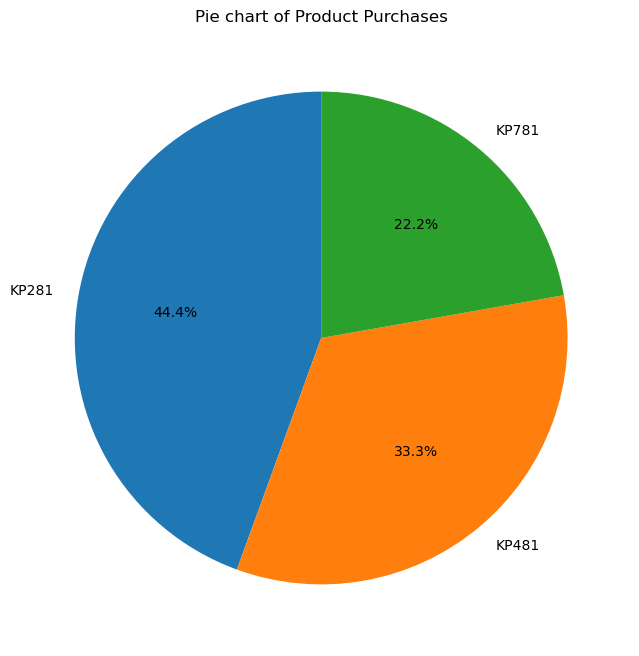

In [27]:
# Pie chart for probabilities

plt.figure(figsize=(8,8))
plt.pie(prod_prob['Percentage'],labels=prod_prob.index,autopct='%1.1f%%',startangle=90)
plt.title('Pie chart of Product Purchases')
plt.show()

# 3. Visual Analysis - Univariate & Bivariate (30 Points)
* For continuous variable(s): Distplot, countplot, histogram for univariate analysis
* For categorical variable(s): Boxplot
* For correlation: Heatmaps, Pairplots

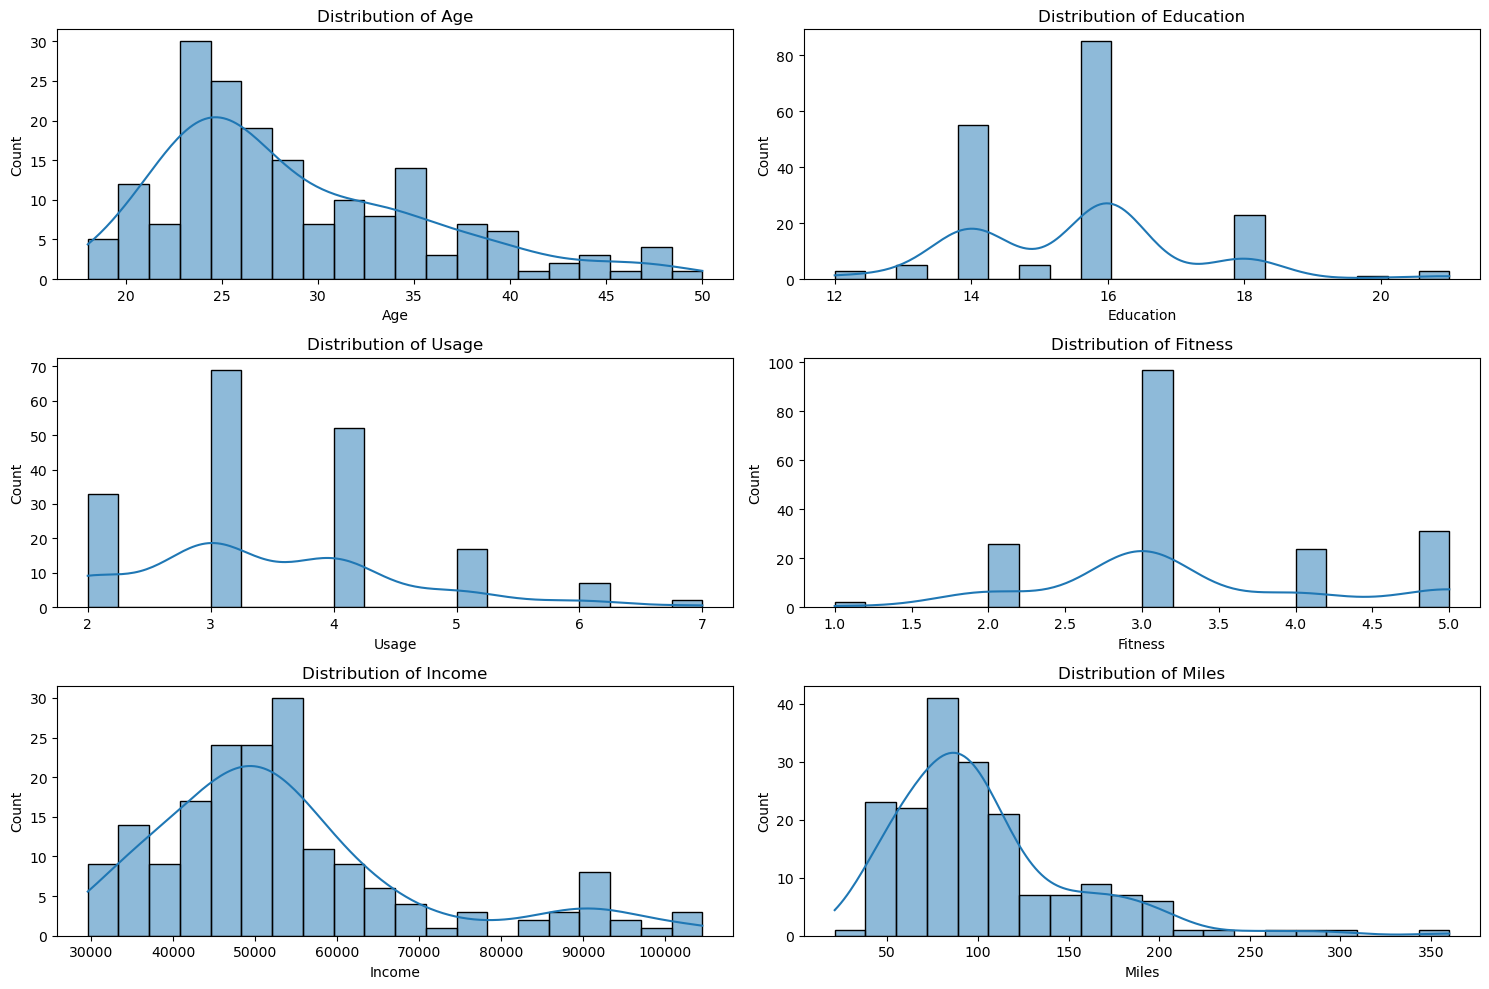

In [28]:
# Create distplots for continuous variables

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_features, 1):
    plt.subplot(3, 2, i)
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

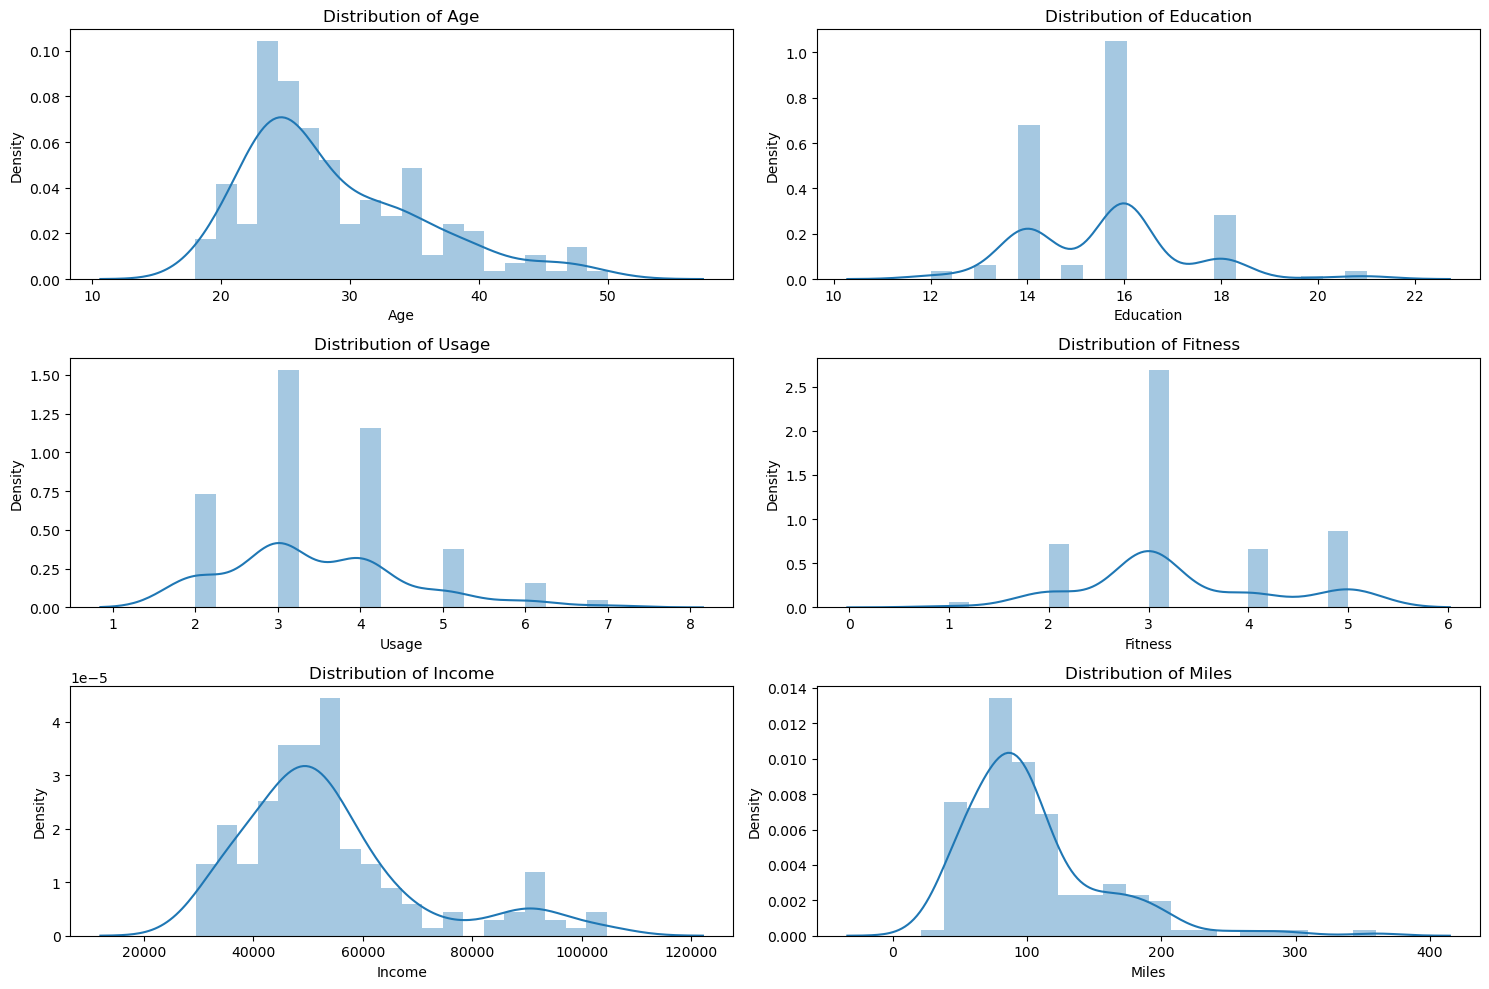

In [29]:
# Create distplots for continuous variables

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_features, 1):
    plt.subplot(3, 2, i)
    sns.distplot(df[col], kde=True, bins=20)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

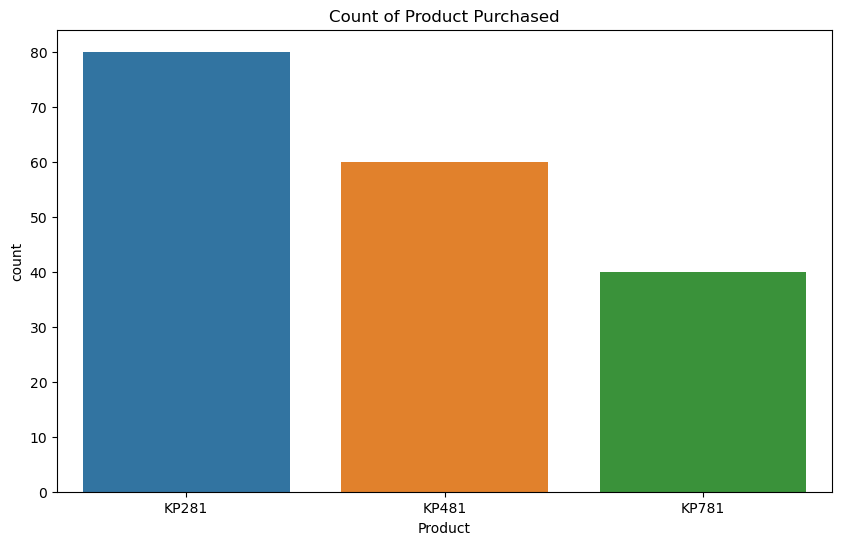

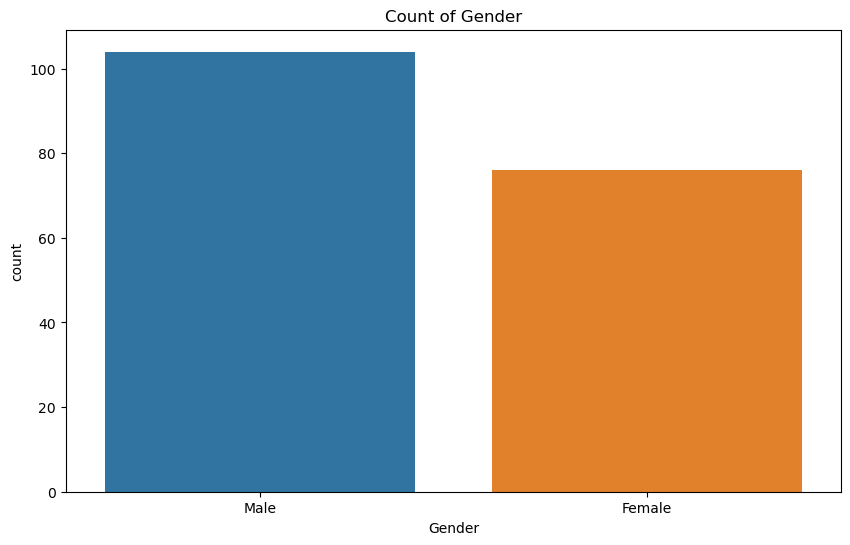

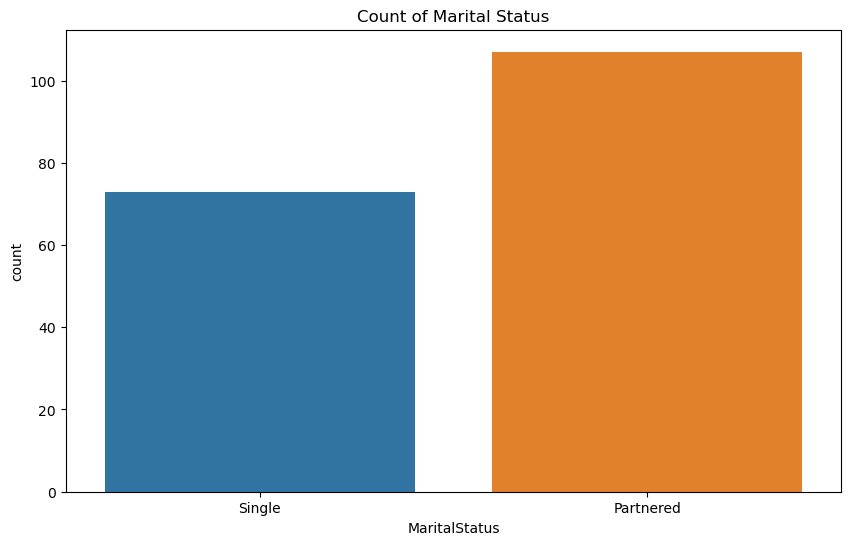

In [30]:
# Countplot for categorical variables

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Product')
plt.title('Count of Product Purchased')
plt.show()

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Gender')
plt.title('Count of Gender')
plt.show()

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='MaritalStatus')
plt.title('Count of Marital Status')
plt.show()


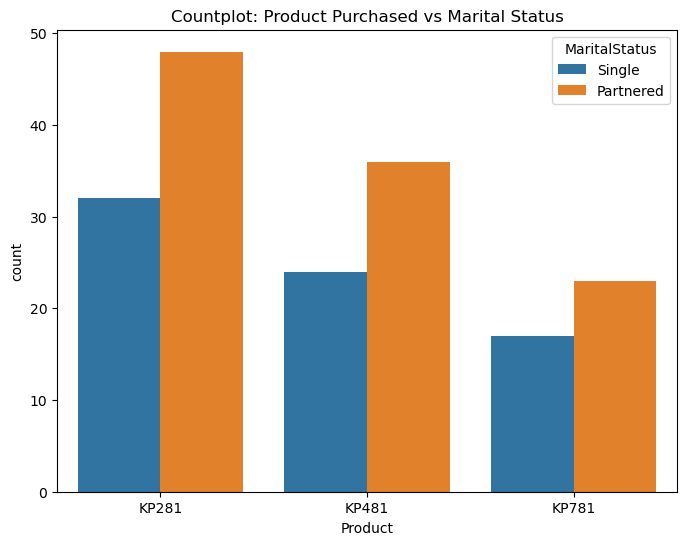

In [31]:
# Countplot for Marital Status and Product Purchased

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Product', hue='MaritalStatus')
plt.title('Countplot: Product Purchased vs Marital Status')
plt.show()

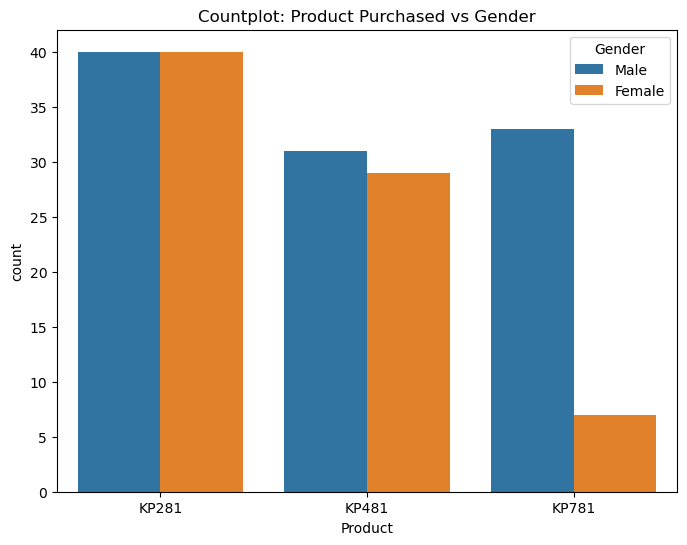

In [32]:
# Countplot for Gender and Product Purchased

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Product', hue='Gender')
plt.title('Countplot: Product Purchased vs Gender')
plt.show()

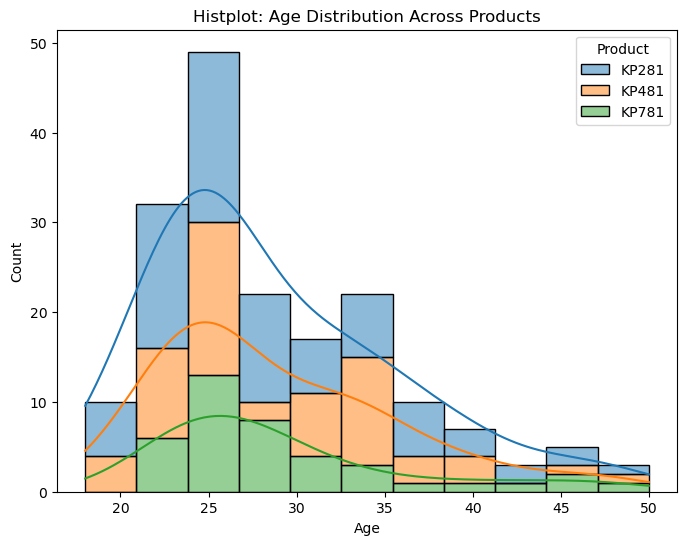

In [33]:
# Histplot for Age and Product Purchased

plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='Age', hue='Product', kde=True, multiple="stack")
plt.title('Histplot: Age Distribution Across Products')
plt.show()

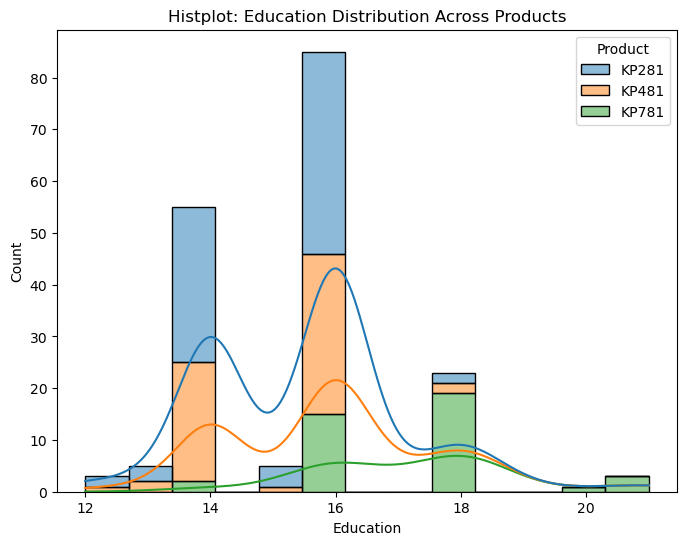

In [34]:
# Histplot for Education and Product Purchased

plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='Education', hue='Product', kde=True, multiple="stack")
plt.title('Histplot: Education Distribution Across Products')
plt.show()

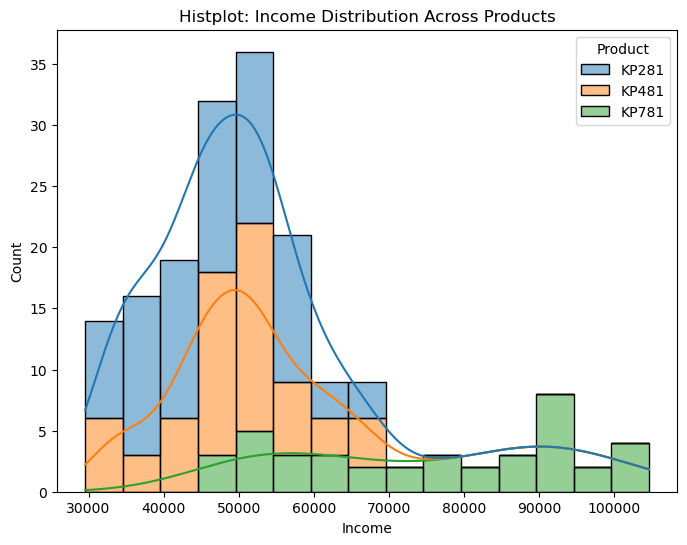

In [35]:
# Histplot for Income and Product Purchased

plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='Income', hue='Product', kde=True, multiple="stack")
plt.title('Histplot: Income Distribution Across Products')
plt.show()

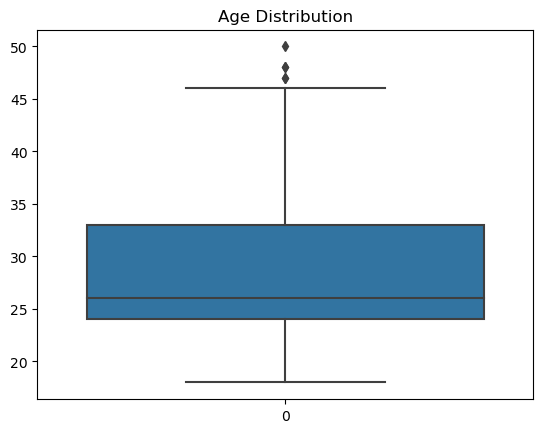

In [36]:
# Box plot for 'Age'

sns.boxplot(df['Age'])
plt.title('Age Distribution')
plt.show()

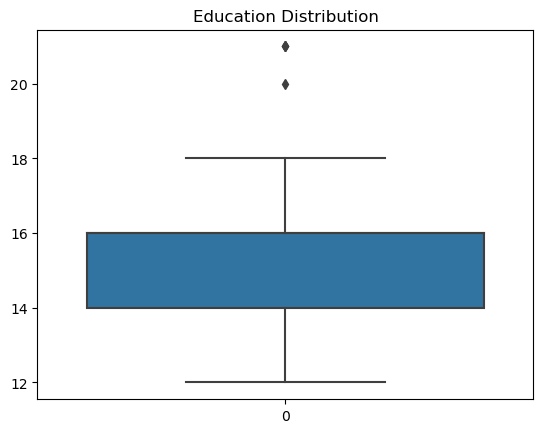

In [37]:
# Box plot for 'Education'

sns.boxplot(df['Education'])
plt.title('Education Distribution')
plt.show()

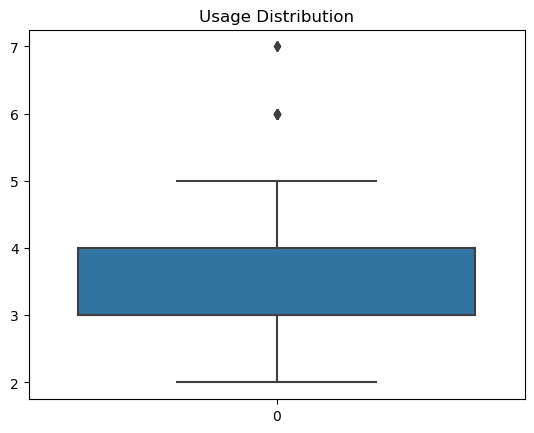

In [38]:
# Box plot for 'Usage'

sns.boxplot(df['Usage'])
plt.title('Usage Distribution')
plt.show()

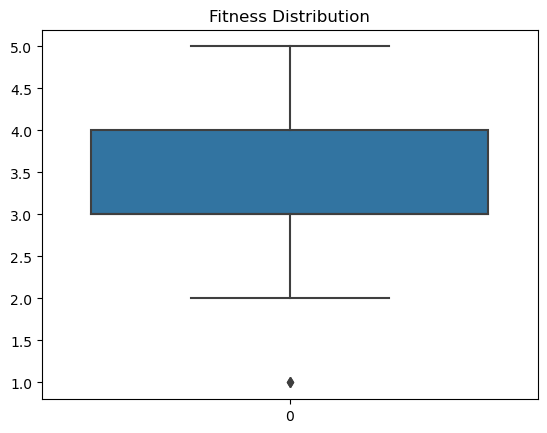

In [39]:
# Box plot for 'Fitness'

sns.boxplot(df['Fitness'])
plt.title('Fitness Distribution')
plt.show()

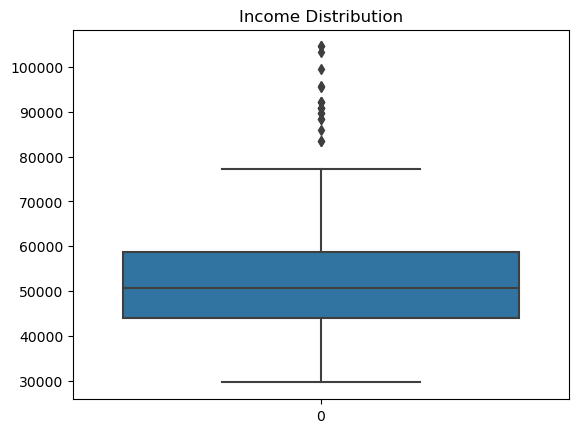

In [40]:
# Box plot for 'Income'

sns.boxplot(df['Income'])
plt.title('Income Distribution')
plt.show()

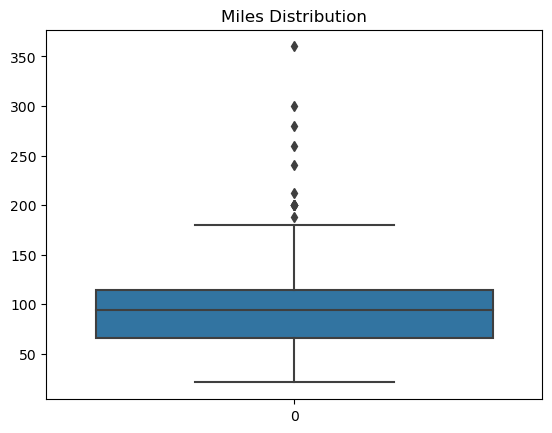

In [41]:
# Box plot for 'Miles'

sns.boxplot(df['Miles'])
plt.title('Miles Distribution')
plt.show()

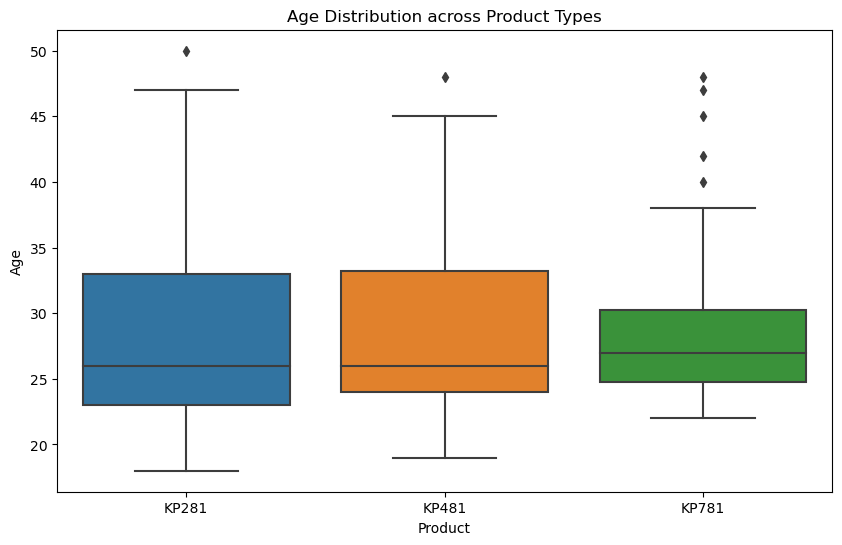

In [42]:
# Boxplot for Age vs Product

plt.figure(figsize=(10, 6))
sns.boxplot(x='Product', y='Age', data=df)
plt.title('Age Distribution across Product Types')
plt.show()


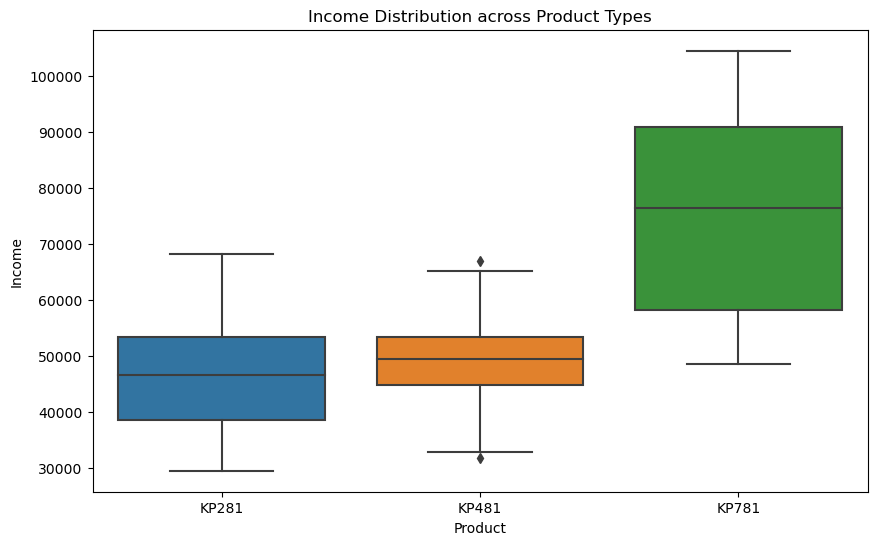

In [43]:
# Boxplot for Income vs Product

plt.figure(figsize=(10, 6))
sns.boxplot(x='Product', y='Income', data=df)
plt.title('Income Distribution across Product Types')
plt.show()

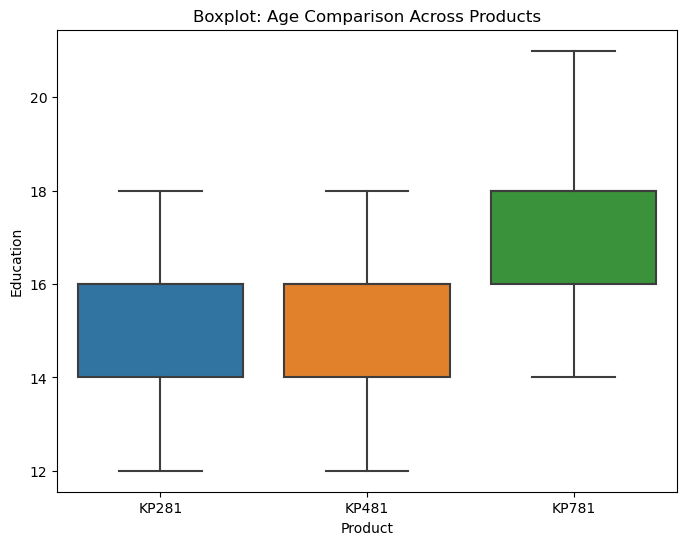

In [44]:
# Boxplot for Eduaction and Product Purchased

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Product', y='Education')
plt.title('Boxplot: Age Comparison Across Products')
plt.show()

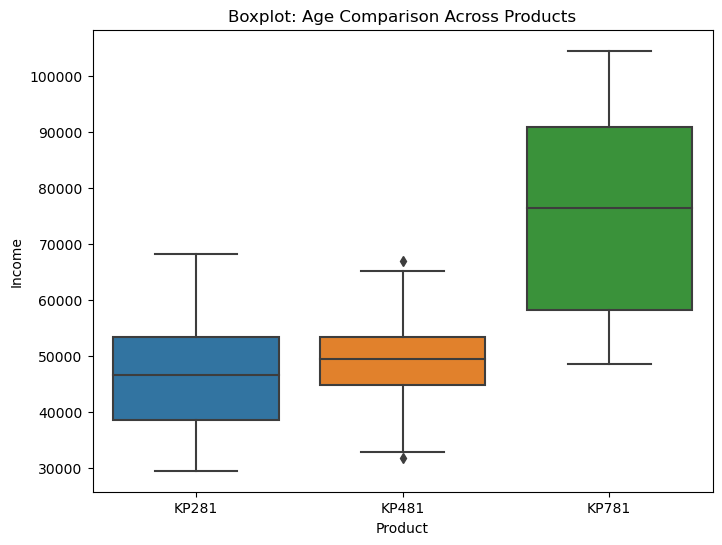

In [45]:
# Boxplot for Income and Product Purchased

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Product', y='Income')
plt.title('Boxplot: Age Comparison Across Products')
plt.show()

In [46]:
# Calculate the correlation matrix for numerical features

corr_matrix = df[['Age', 'Education', 'Usage', 'Fitness', 'Income', 'Miles']].corr()

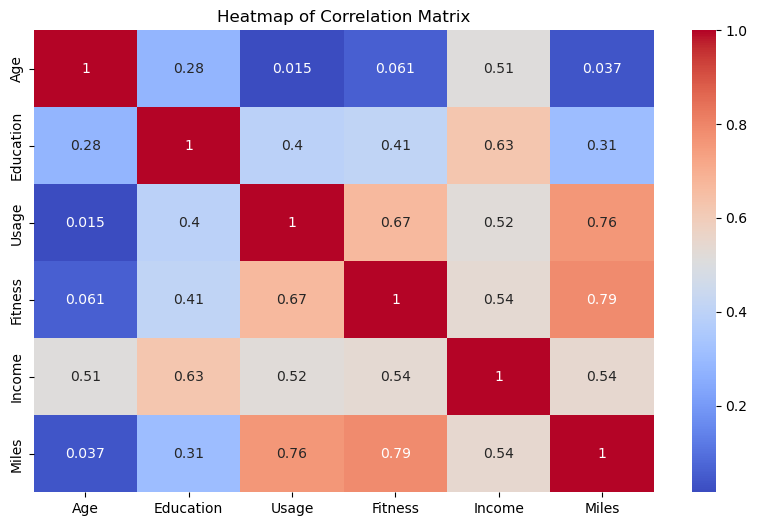

In [47]:
# Plotting the heat map

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Heatmap of Correlation Matrix')
plt.show()

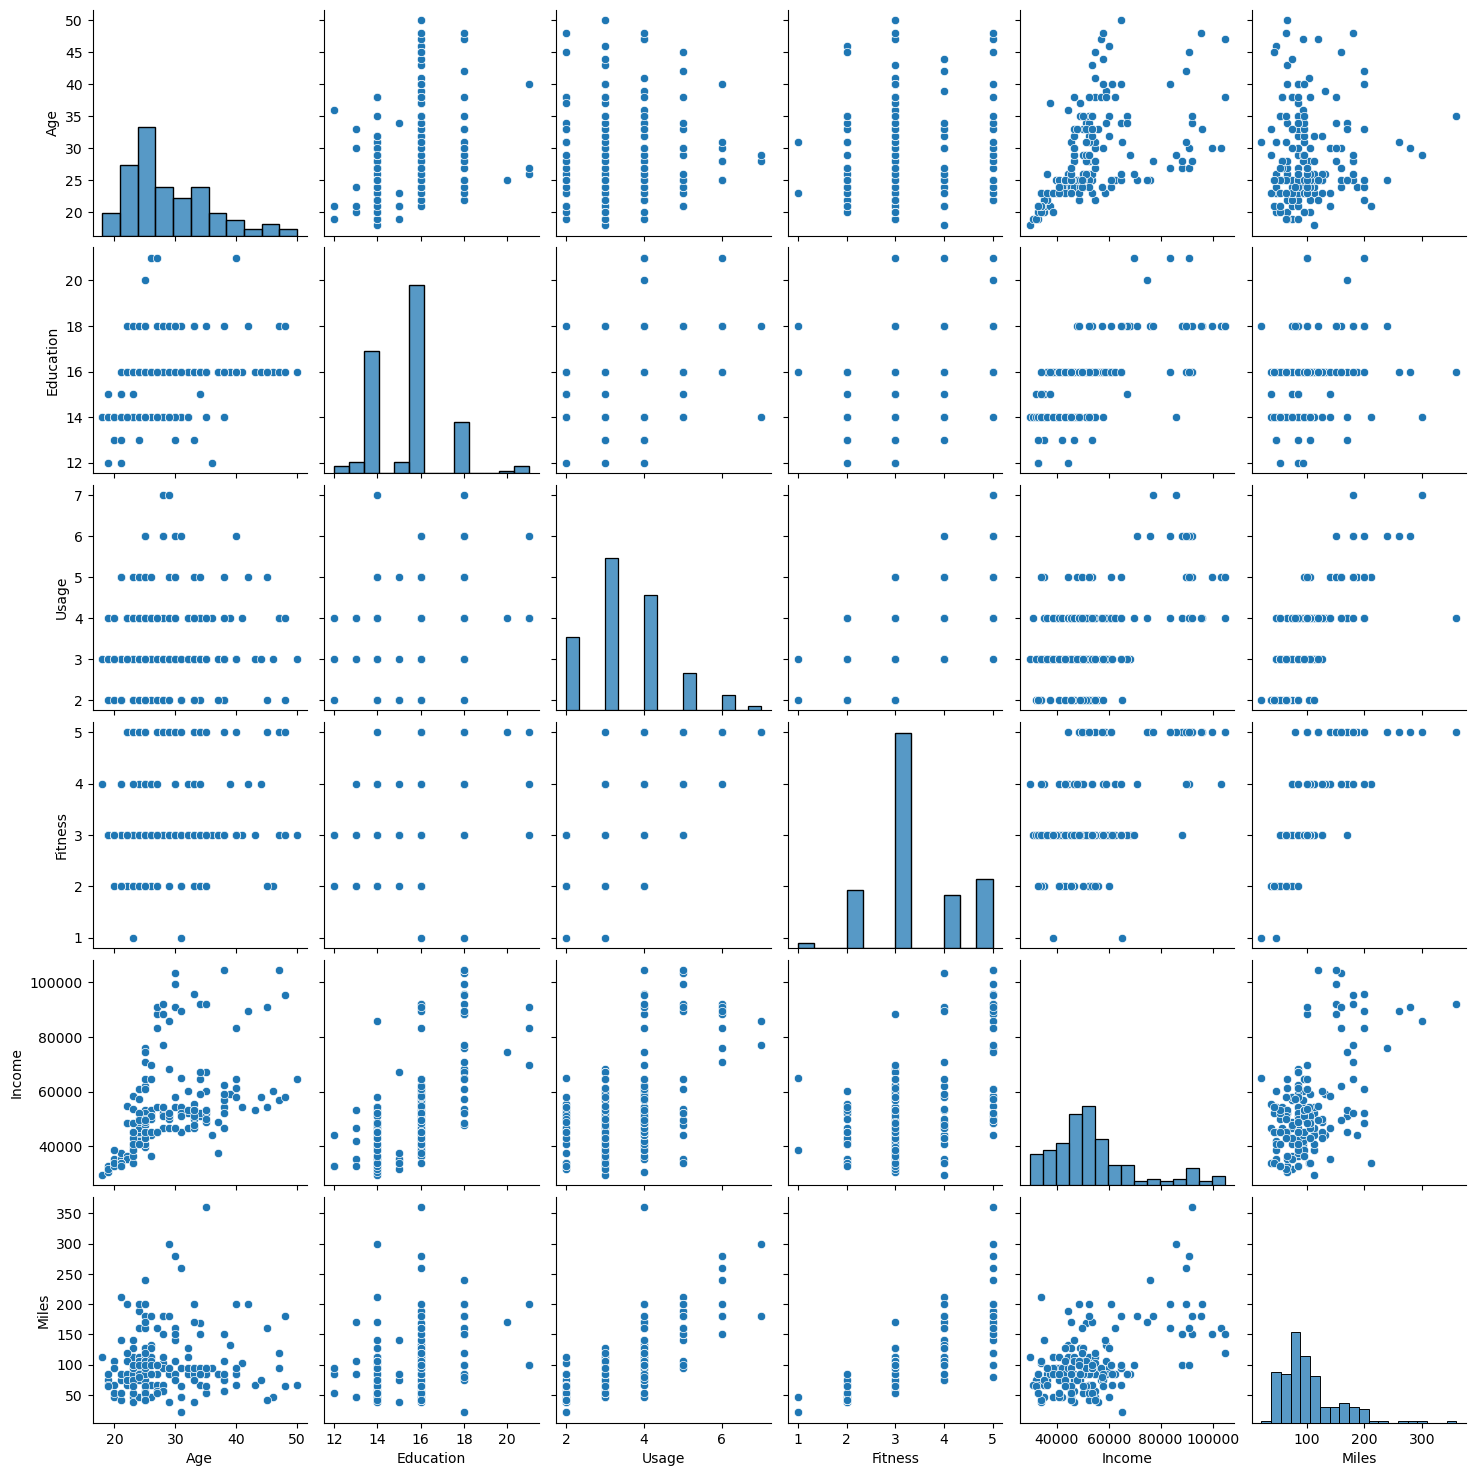

In [48]:
# Pair plot between numerical features

sns.pairplot(df[['Age', 'Education', 'Usage', 'Fitness', 'Income', 'Miles']])
plt.show()

# 4. Missing Value & Outlier Detection

In [49]:
# Checking for missing values

df.isnull().sum()

Product          0
Age              0
Gender           0
Education        0
MaritalStatus    0
Usage            0
Fitness          0
Income           0
Miles            0
Age Group        0
Income Group     0
Fitness Group    0
dtype: int64

In [50]:
# Checking for duplicates

df.duplicated().sum()

0

In [51]:
numerical_features

['Age', 'Education', 'Usage', 'Fitness', 'Income', 'Miles']

In [52]:
# Descriptive statistics for numeric columns

desc_stats = df[numerical_features].describe()

In [53]:
# Calculate IQR

Q1 = desc_stats.loc['25%']
Q3 = desc_stats.loc['75%']
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [54]:
# Check for outliers

outliers = {}
for col in numerical_features:
    outlier_mask = (df[col] < lower_bound[col]) | (df[col] > upper_bound[col])
    outliers[col] = df[outlier_mask]


for col, outlier_data in outliers.items():
    print(f'Outliers in {col}:')
    print(outlier_data)
    print('---')

Outliers in Age:
    Product  Age  Gender  Education MaritalStatus  Usage  Fitness  Income  \
78    KP281   47    Male         16     Partnered      4        3   56850   
79    KP281   50  Female         16     Partnered      3        3   64809   
139   KP481   48    Male         16     Partnered      2        3   57987   
178   KP781   47    Male         18     Partnered      4        5  104581   
179   KP781   48    Male         18     Partnered      4        5   95508   

     Miles Age Group Income Group Fitness Group  
78      94     45-54       Medium       Average  
79      66     45-54       Medium       Average  
139     64     45-54       Medium       Average  
178    120     45-54         High          Good  
179    180     45-54         High          Good  
---
Outliers in Education:
    Product  Age  Gender  Education MaritalStatus  Usage  Fitness  Income  \
156   KP781   25    Male         20     Partnered      4        5   74701   
157   KP781   26  Female         21    

# 5. Business Insights based on Non-Graphical and Visual Analysis

### 5.1 Comments on the range of attributes

1. Age Distribution (Continuous Variable)
    - AeroFit may more successfully focus their marketing campaigns by emphasizing aspects that correspond with their main client base by knowing which age groups are most likely to use their products.

2. Income Distribution (Continuous Variable)
    - This insight can inform pricing strategies. AeroFit may promote entry-level models like KP281 to low-income groups and premium models like KP781 to higher-income groups.

3. Product Purchased (Categorical Variable)
    - AeroFit could analyze the features of KP481 and promote those features in other models, or improve KP781's features to boost its sales. Alternatively, they can push KP281 to budget-conscious customers.

4. Gender Breakdown (Categorical Variable)
    - Marketing plans tailored to a given gender can be created. For example, if men are the main consumers of high-end models, marketing can emphasize features and performance, while advertising for women might highlight space-saving, convenience, or health benefits.

5. Usage and Fitness Levels (Continuous Variables)
    - This implies the possibility of many product categories. While entry-level machines can be marketed to casual consumers, advanced treadmills can be marketed to fitness-conscious clients.

6. Marital Status (Categorical Variable)
    - If married people predominate, it can mean that families or couples are buying treadmills to use at home. This may have an impact on marketing, for example, by highlighting qualities like safety or family use.

7. Bivariate Analysis
    - This allows AeroFit to segment their consumer base, delivering unique incentives for different income and age groups. Moreover, it can direct upgrade offers and product bundling according to user demographics.

### 5.2 Comments on the distribution of the variables and relationship between them

1. Income and Product Choice:
    * Higher-income customers strongly prefer the advanced KP781 model, while middle-income customers lean towards KP481. Lower-income customers prefer KP281. This segmentation can help AeroFit tailor its marketing and pricing strategies.

2. Age and Product Preference:
    * Older customers are more likely to purchase high-end models, possibly due to higher disposable income or a focus on more advanced features for better performance. Younger customers tend to buy mid-range or entry-level models.

3. Usage and Product Type:
    * Customers who intend to use the treadmill more frequently are willing to pay for advanced models, indicating that KP781 is perceived as better suited for fitness enthusiasts. Casual users are satisfied with the more basic KP281.

4. Fitness and Product Choice:
    * Self-rated fitness correlates with the treadmill model purchased. Higher fitness levels correlate with the purchase of advanced models like KP781, while customers who rate their fitness lower may opt for simpler treadmills.

5. Gender and Product Preference:
    * While gender doesn’t show a strong overall influence, males might lean toward premium models like KP781, and females may prefer mid-range models like KP481. This subtle distinction could inform how AeroFit presents its products to different gender demographics.

### 5.3 Comments for each univariate and bivariate plot

### Univariate Plots

1. Age Distribution (Histogram/Distplot)
    - The broad range of ages indicates that AeroFit's customer base is diverse, but younger buyers may make up the majority of the market. This suggests that marketing campaigns should focus on younger demographics but not exclude older customers, especially for higher-end models like KP781.

2. Income Distribution (Histogram/Boxplot)
    - AeroFit appears to have a niche among higher-income consumers, despite drawing clients from a range of economic backgrounds, as indicated by the skewed income distribution. AeroFit can employ financing alternatives to draw lower-income clients to mid-range models while targeting higher-income customers with premium items.

3. Gender Distribution (Countplot)
    - Gender doesn't play a major role in determining customer base, but the slight preference for higher-end products among males can inform gender-targeted marketing. For instance, emphasizing performance and technology may appeal to male buyers.

4. Marital Status (Countplot)
    - Married customers may be buying treadmills for family use, so marketing strategies should emphasize the durability, safety, and family-oriented features of AeroFit products. Partnered individuals may have higher combined incomes, making them more likely to purchase mid- to high-end products.

5. Usage (Distplot/Boxplot)
    - AeroFit may want to offer incentives or programs for customers who intend to use the treadmill frequently. More frequent users are likely fitness enthusiasts, who may be interested in advanced features or accessories.

6. Fitness (Distplot/Boxplot)
    - Since most customers are self-assessing as reasonably fit, AeroFit can target its marketing towards improving fitness for the average customer. For higher fitness levels, products like KP781 can be marketed as tools for serious fitness enthusiasts.

7. Product Purchased (Countplot/Pie Chart)
    - KP481 hits a sweet spot in terms of price and features. AeroFit could focus on promoting KP481's benefits more heavily to other customer segments. Additionally, promoting KP781 as a premium product with added value could improve its market share.

### Bivariate Plots

1. Age vs. Product (Boxplot)
    - This correlation suggests that older customers have both the disposable income and preference for advanced features. AeroFit should market high-end products like KP781 to older buyers, while positioning KP281 and KP481 for younger, budget-conscious buyers.

2. Income vs. Product (Boxplot)
    - Income plays a critical role in product choice. AeroFit can offer financing or payment plans to make the mid-range KP481 accessible to more customers, while positioning KP781 as a luxury product for affluent buyers.

3. Usage vs. Product (Boxplot)
    - Frequent treadmill users value the advanced features of KP781, which may support higher-intensity workouts. AeroFit should highlight these features in marketing to fitness enthusiasts, while promoting KP281 as a good choice for casual exercisers.

4. Fitness vs. Product (Boxplot)
    - Self-perceived fitness level is a strong predictor of product choice. AeroFit can target KP781 towards fitness enthusiasts looking for advanced equipment, while promoting KP281 as an easy-to-use product for beginners.

5. Marital Status vs. Product (Countplot)
    - This suggests that married customers, who might have dual incomes, are willing to invest more in premium products. AeroFit can emphasize features like safety and durability for family use when marketing to partnered customers.

6. Gender vs. Product (Countplot)
    - This distinction can guide targeted marketing efforts. For example, promoting advanced performance features for KP781 might appeal more to male buyers, while focusing on practicality and value for KP481 could resonate with female customers.

# 6. Recommendations - Actionable items for business

1. Target High-Income Customers with Premium Models (KP781)
    - Create exclusive marketing campaigns aimed at high-income individuals. Highlight the advanced features of the KP781 model, focusing on durability, performance, and fitness tracking capabilities.

2. Offer Flexible Payment Plans for Mid-Range Products (KP481)
    - Introduce financing options or monthly installment plans for the KP481 treadmill to make it more accessible to middle-income customers.

3. Create Fitness Challenges or Loyalty Programs for Frequent Users
    - Launch a loyalty program or fitness challenge for customers who use their treadmills regularly (4+ times a week). Offer rewards like discounts on accessories or fitness-related services.

4. Design Marketing Campaigns Based on Age Segments
    - Develop age-specific marketing strategies. For younger customers, focus on the affordability and practicality of KP281 and KP481. For older customers, emphasize the advanced technology and ease of use of KP781.

5. Focus on Family-Friendly Features for Married Customers
    - Highlight family-oriented features like safety, durability, and long-term investment benefits in your marketing to married/partnered customers.

6. Promote Entry-Level Models (KP281) to First-Time Buyers
    - Create promotional packages for first-time treadmill buyers that include KP281, offering bundled accessories like fitness mats, or short-term maintenance plans.

7. Use Gender-Specific Advertising to Highlight Key Features
    - Use gender-specific messaging in advertisements. For male customers, emphasize performance, power, and high-tech features. For female customers, focus on practical benefits, ease of use, and fitness outcomes.

8. Capitalize on Fitness Trends with KP781
    - Position KP781 as the go-to treadmill for fitness enthusiasts and athletes by partnering with gyms, fitness influencers, and professional trainers.

9. Offer Personalized Recommendations for Returning Customers
    - Implement a personalized recommendation engine that suggests products based on a customer's fitness level, usage habits, and income.

10. Host Free Fitness Webinars or Workshops
    - Host free online webinars or fitness workshops where trainers guide customers on how to maximize their workouts with AeroFit treadmills. Offer special discounts to participants.